## 26 — GDSC Pharmacology Integration

### Objective

Integrate GDSC pharmacogenomic measurements with the harmonized modeling cohort generated in previous notebooks.

This notebook focuses exclusively on data integration, identifier validation, coverage assessment, and pharmacological data auditing.

No biological interpretation, resistance-like phenotype construction, or association analyses are performed at this stage.

### Key Questions

- How many harmonized models have pharmacological information available?
- How robust is the COSMICID mapping between GDSC and the harmonized cohort?
- Which cancer lineages retain adequate pharmacological coverage?
- How complete is drug-response coverage across compounds?
- Are there potential sources of pharmacological leakage that should be documented before downstream analyses?

### Expected Outputs

- Integrated pharmacology cohort
- GDSC coverage reports
- Drug metadata table
- Drug-response matrix
- Preliminary leakage-risk assessment

### Notes

This notebook corresponds to the pharmacological integration layer of the framework and serves as the foundation for subsequent resistance-like phenotype construction.

---

In [1]:
# =============================================================================
# Imports
# =============================================================================

from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

# Plot settings
plt.style.use("default")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

RANDOM_STATE = 42

In [2]:
# =============================================================================
# Load datasets
# =============================================================================

from pathlib import Path

DATA_DIR = Path("../../data")

cohort_path = (
    DATA_DIR / "interim" / "22_integrated_modeling_cohort.csv"
)

expression_path = (
    DATA_DIR / "interim" / "23_expression_harmonized.parquet"
)

gdsc_path = (
    DATA_DIR
    / "raw"
    / "gdsc"
    / "GDSC2_fitted_dose_response_27Oct23.xlsx"
)

cohort = pd.read_csv(cohort_path)

expression = pd.read_parquet(expression_path)

gdsc = pd.read_excel(gdsc_path)

print(f"Cohort shape     : {cohort.shape}")
print(f"Expression shape : {expression.shape}")
print(f"GDSC shape       : {gdsc.shape}")

Cohort shape     : (713, 8)
Expression shape : (713, 19194)
GDSC shape       : (242036, 16)


In [3]:
# =============================================================================
# Dataset overview
# =============================================================================

print("=" * 80)
print("COHORT")
print("=" * 80)
display(cohort.head())

print("\nColumns:", len(cohort.columns))
print(cohort.columns.tolist())

print("\n")

print("=" * 80)
print("EXPRESSION")
print("=" * 80)
print("Shape:", expression.shape)

print("\n")

print("=" * 80)
print("GDSC")
print("=" * 80)
display(gdsc.head())

print("\nColumns:", len(gdsc.columns))
print(gdsc.columns.tolist())

COHORT


,ModelID,SangerModelID,COSMICID,CellLineName,OncotreeLineage,OncotreePrimaryDisease,OncotreeSubtype,CCLEName
0,ACH-000001,SIDM00105,905933.0,NIH:OVCAR-3,Ovary/Fallopian Tube,Ovarian Epithelial Tumor,High-Grade Serous Ovarian Cancer,NIHOVCAR3_OVARY
1,ACH-000002,SIDM00829,905938.0,HL-60,Myeloid,Acute Myeloid Leukemia,Acute Myeloid Leukemia,HL60_HAEMATOPOIETIC_AND_LYMPHOID_TISSUE
2,ACH-000004,SIDM00594,907053.0,HEL,Myeloid,Acute Myeloid Leukemia,Acute Myeloid Leukemia,HEL_HAEMATOPOIETIC_AND_LYMPHOID_TISSUE
3,ACH-000006,SIDM01023,908148.0,MONO-MAC-6,Myeloid,Acute Myeloid Leukemia,Acute Monoblastic/Monocytic Leukemia,MONOMAC6_HAEMATOPOIETIC_AND_LYMPHOID_TISSUE
4,ACH-000007,SIDM00677,907795.0,LS513,Bowel,Colorectal Adenocarcinoma,Colon Adenocarcinoma,LS513_LARGE_INTESTINE



Columns: 8
['ModelID', 'SangerModelID', 'COSMICID', 'CellLineName', 'OncotreeLineage', 'OncotreePrimaryDisease', 'OncotreeSubtype', 'CCLEName']


EXPRESSION
Shape: (713, 19194)


GDSC


,DATASET,NLME_RESULT_ID,NLME_CURVE_ID,CELL_LINE_NAME,SANGER_MODEL_ID,CANCER_TYPE,DRUG_ID,DRUG_NAME,PUTATIVE_TARGET,PATHWAY_NAME,MIN_CONC,MAX_CONC,LN_IC50,AUC,RMSE,Z_SCORE
0,GDSC2,343,15946310,PFSK-1,SIDM01132,Other Solid Cancers,1003,Camptothecin,TOP1,DNA replication,0.0001,0.1,-1.463887,0.930220,0.089052,0.433123
1,GDSC2,343,15946548,A673,SIDM00848,Ewing's Sarcoma,1003,Camptothecin,TOP1,DNA replication,0.0001,0.1,-4.869455,0.614970,0.111351,-1.421100
2,GDSC2,343,15946830,ES5,SIDM00263,Ewing's Sarcoma,1003,Camptothecin,TOP1,DNA replication,0.0001,0.1,-3.360586,0.791072,0.142855,-0.599569
3,GDSC2,343,15947087,ES7,SIDM00269,Ewing's Sarcoma,1003,Camptothecin,TOP1,DNA replication,0.0001,0.1,-5.044940,0.592660,0.135539,-1.516647
4,GDSC2,343,15947369,EW-11,SIDM00203,Ewing's Sarcoma,1003,Camptothecin,TOP1,DNA replication,0.0001,0.1,-3.741991,0.734047,0.128059,-0.807232



Columns: 16
['DATASET', 'NLME_RESULT_ID', 'NLME_CURVE_ID', 'CELL_LINE_NAME', 'SANGER_MODEL_ID', 'CANCER_TYPE', 'DRUG_ID', 'DRUG_NAME', 'PUTATIVE_TARGET', 'PATHWAY_NAME', 'MIN_CONC', 'MAX_CONC', 'LN_IC50', 'AUC', 'RMSE', 'Z_SCORE']


## GDSC Dataset Audit

Before integrating pharmacological measurements into the harmonized cohort, we first characterize the structure and coverage of the GDSC dataset.

Particular attention is given to:

- model coverage,
- drug coverage,
- pathway representation,
- target annotations,
- and identifier compatibility with the harmonized cohort.

In [4]:
# =============================================================================
# GDSC overview
# =============================================================================

print(f"Rows                  : {len(gdsc):,}")
print(f"Unique cell lines     : {gdsc['SANGER_MODEL_ID'].nunique():,}")
print(f"Unique drugs          : {gdsc['DRUG_ID'].nunique():,}")
print(f"Unique drug names     : {gdsc['DRUG_NAME'].nunique():,}")
print(f"Unique targets        : {gdsc['PUTATIVE_TARGET'].nunique():,}")
print(f"Unique pathways       : {gdsc['PATHWAY_NAME'].nunique():,}")

Rows                  : 242,036
Unique cell lines     : 969
Unique drugs          : 295
Unique drug names     : 286
Unique targets        : 185
Unique pathways       : 24


In [5]:
# =============================================================================
# Cohort ↔ GDSC overlap
# =============================================================================

cohort_models = set(cohort["SangerModelID"])

gdsc_models = set(gdsc["SANGER_MODEL_ID"])

shared_models = cohort_models.intersection(gdsc_models)

print(f"Cohort models      : {len(cohort_models):,}")
print(f"GDSC models        : {len(gdsc_models):,}")
print(f"Shared models      : {len(shared_models):,}")

print(
    f"Coverage (%)       : "
    f"{100 * len(shared_models) / len(cohort_models):.2f}"
)

Cohort models      : 713
GDSC models        : 969
Shared models      : 713
Coverage (%)       : 100.00


In [6]:
# =============================================================================
# Integrated pharmacology cohort
# =============================================================================

pharmacology_cohort = cohort[
    cohort["SangerModelID"].isin(shared_models)
].copy()

print(pharmacology_cohort.shape)

display(pharmacology_cohort.head())

(713, 8)


,ModelID,SangerModelID,COSMICID,CellLineName,OncotreeLineage,OncotreePrimaryDisease,OncotreeSubtype,CCLEName
0,ACH-000001,SIDM00105,905933.0,NIH:OVCAR-3,Ovary/Fallopian Tube,Ovarian Epithelial Tumor,High-Grade Serous Ovarian Cancer,NIHOVCAR3_OVARY
1,ACH-000002,SIDM00829,905938.0,HL-60,Myeloid,Acute Myeloid Leukemia,Acute Myeloid Leukemia,HL60_HAEMATOPOIETIC_AND_LYMPHOID_TISSUE
2,ACH-000004,SIDM00594,907053.0,HEL,Myeloid,Acute Myeloid Leukemia,Acute Myeloid Leukemia,HEL_HAEMATOPOIETIC_AND_LYMPHOID_TISSUE
3,ACH-000006,SIDM01023,908148.0,MONO-MAC-6,Myeloid,Acute Myeloid Leukemia,Acute Monoblastic/Monocytic Leukemia,MONOMAC6_HAEMATOPOIETIC_AND_LYMPHOID_TISSUE
4,ACH-000007,SIDM00677,907795.0,LS513,Bowel,Colorectal Adenocarcinoma,Colon Adenocarcinoma,LS513_LARGE_INTESTINE


In [7]:
# =============================================================================
# Missing models audit
# =============================================================================

missing_models = cohort[
    ~cohort["SangerModelID"].isin(shared_models)
].copy()

print(f"Models without GDSC data: {len(missing_models):,}")

Models without GDSC data: 0


## Cohort Integration Summary

All models present in the harmonized transcriptomic cohort were successfully matched to GDSC pharmacological measurements through SangerModelID.

No additional model attrition was introduced during pharmacological integration.

As a consequence, the integrated pharmacogenomic cohort retains the complete transcriptomic modeling universe generated in previous notebooks.

This result substantially simplifies downstream resistance-like phenotype construction and reduces the risk of lineage-specific coverage losses introduced by pharmacological data availability.

---

In [8]:
# =============================================================================
# Lineage coverage
# =============================================================================

lineage_counts = (
    pharmacology_cohort
    .groupby("OncotreeLineage")
    .size()
    .sort_values(ascending=False)
    .rename("Models")
)

display(lineage_counts.to_frame())

,Models
OncotreeLineage,
Lung,136
Lymphoid,86
Esophagus/Stomach,51
Breast,47
Bowel,43
CNS/Brain,37
Skin,37
Ovary/Fallopian Tube,34
Myeloid,32


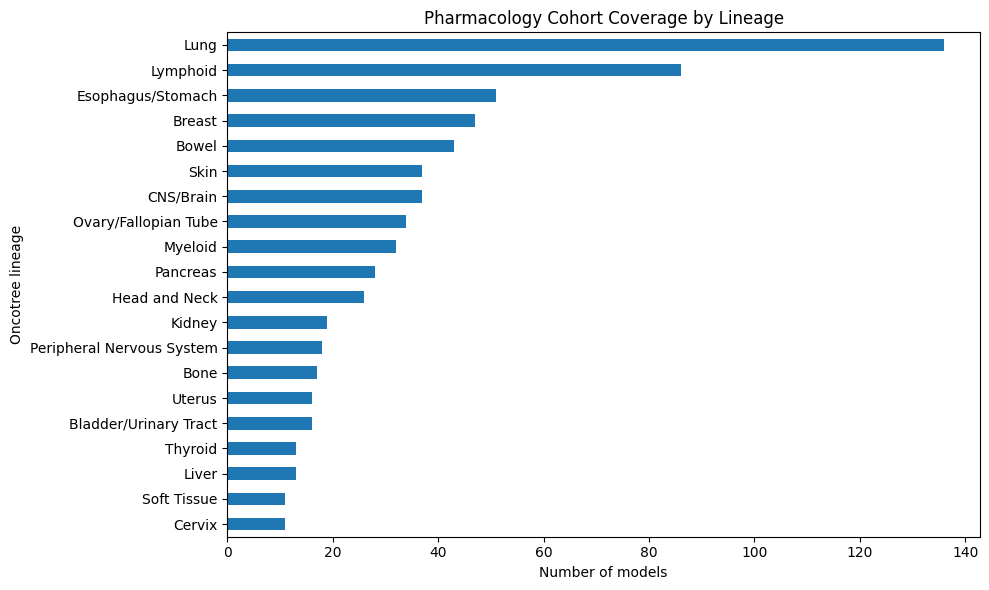

In [9]:
# =============================================================================
# Top represented lineages
# =============================================================================

plt.figure(figsize=(10, 6))

lineage_counts.head(20).sort_values().plot(kind="barh")

plt.xlabel("Number of models")
plt.ylabel("Oncotree lineage")
plt.title("Pharmacology Cohort Coverage by Lineage")

plt.tight_layout()
plt.show()

In [10]:
drug_coverage = (
    gdsc
    .groupby("DRUG_NAME")["SANGER_MODEL_ID"]
    .nunique()
    .sort_values(ascending=False)
)

drug_coverage.describe()

count    286.000000
mean     824.293706
std      175.267528
min      225.000000
25%      717.000000
50%      894.000000
75%      957.750000
max      969.000000
Name: SANGER_MODEL_ID, dtype: float64

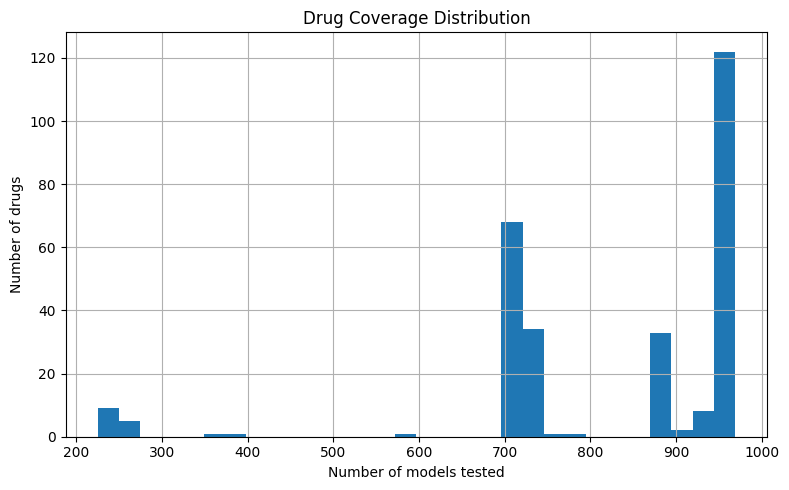

In [11]:
# =============================================================================
# Drug coverage distribution
# =============================================================================

plt.figure(figsize=(8, 5))

drug_coverage.hist(bins=30)

plt.xlabel("Number of models tested")
plt.ylabel("Number of drugs")
plt.title("Drug Coverage Distribution")

plt.tight_layout()
plt.show()

In [12]:
# =============================================================================
# Lowest coverage drugs
# =============================================================================

drug_coverage.sort_values().head(20)

DRUG_NAME
Piperlongumine    225
CHIR-99021        225
SL0101            225
CCT-018159        225
Elesclomol        225
BX795             225
Bicalutamide      225
IOX2              225
Tretinoin         225
SB505124          265
AZD6482           267
PF-4708671        268
GSK269962A        268
Tozasertib        268
Remodelin         370
TW 37             376
Daporinad         595
Eg5_9814          713
AZD5991           713
IAP_5620          714
Name: SANGER_MODEL_ID, dtype: int64

In [13]:
pathway_counts = (
    gdsc["PATHWAY_NAME"]
    .value_counts()
)

display(pathway_counts)

PATHWAY_NAME
Unclassified                         24979
PI3K/MTOR signaling                  22724
Other                                21402
DNA replication                      17650
Other, kinases                       17277
ERK MAPK signaling                   13350
Genome integrity                     12221
Cell cycle                           11620
Apoptosis regulation                 10828
Chromatin histone methylation        10612
RTK signaling                        10573
Chromatin other                       8576
Chromatin histone acetylation         8162
WNT signaling                         7631
Protein stability and degradation     7087
EGFR signaling                        6734
Mitosis                               6453
IGF1R signaling                       5512
Metabolism                            4802
Hormone-related                       3820
p53 pathway                           3776
Cytoskeleton                          3387
JNK and p38 signaling                 190

In [14]:
target_counts = (
    gdsc["PUTATIVE_TARGET"]
    .value_counts()
)

display(target_counts.head(30))

PUTATIVE_TARGET
PARP1, PARP2                4714
MEK1, MEK2                  4547
TOP1                        4325
EGFR                        3836
TNKS1, TNKS2                3699
AKT1, AKT2, AKT3            3308
DOT1L                       2873
IGF1R, IR                   2872
BRAF                        2859
ATR                         2803
PORCN                       2751
ERK1, ERK2                  2662
DNA alkylating agent        2649
Microtubule stabiliser      2595
BRD4                        2556
HSP90                       2363
Antimetabolite              2341
MCL1                        2199
Mutant RAS                  2193
EGFR, ERBB2                 1932
CDK4, CDK6                  1927
FGFR1, FGFR2, FGFR3         1926
IGF1R                       1924
MDM2                        1916
PI3K (beta sparing)         1916
PI3Kalpha                   1909
SYK                         1788
BRD2, BRD3, BRD4            1786
MTORC1, MTORC2              1705
Microtubule destabiliser   

In [15]:
print(
    "Unique targets:",
    gdsc["PUTATIVE_TARGET"].nunique()
)

Unique targets: 185


## Pharmacological Metadata Summary

The integrated pharmacogenomic layer exhibits:

- complete model overlap with the harmonized transcriptomic cohort,
- broad drug coverage across the majority of compounds,
- extensive representation of major oncology pathways,
- rich target-level annotations spanning 185 distinct target classes.

Target annotations appear substantially more informative than pathway annotations and are expected to represent the primary source for future drug-family grouping and leakage-control strategies.

Several pharmacological classes are represented by multiple compounds targeting the same biological processes, highlighting the importance of explicit drug-family awareness in downstream analyses.

In [16]:
# =============================================================================
# Build output artifacts
# =============================================================================

# Cohort with pharmacology coverage
integrated_pharmacology_cohort = pharmacology_cohort.copy()

# Drug metadata
drug_metadata = (
    gdsc[
        [
            "DRUG_ID",
            "DRUG_NAME",
            "PUTATIVE_TARGET",
            "PATHWAY_NAME"
        ]
    ]
    .drop_duplicates()
    .sort_values(["DRUG_ID", "DRUG_NAME"])
    .reset_index(drop=True)
)

# Drug-response table
drug_response = (
    gdsc[
        [
            "SANGER_MODEL_ID",
            "DRUG_ID",
            "DRUG_NAME",
            "PUTATIVE_TARGET",
            "PATHWAY_NAME",
            "LN_IC50",
            "AUC",
            "Z_SCORE",
            "RMSE"
        ]
    ]
    .copy()
)

print("Integrated pharmacology cohort:", integrated_pharmacology_cohort.shape)
print("Drug metadata:", drug_metadata.shape)
print("Drug response:", drug_response.shape)

Integrated pharmacology cohort: (713, 8)
Drug metadata: (295, 4)
Drug response: (242036, 9)


In [17]:
# =============================================================================
# Save outputs
# =============================================================================

OUTPUT_DIR = DATA_DIR / "interim"
OUTPUT_DIR.mkdir(exist_ok=True)

integrated_pharmacology_cohort.to_csv(
    OUTPUT_DIR / "26_integrated_pharmacology_cohort.csv",
    index=False
)

drug_metadata.to_csv(
    OUTPUT_DIR / "26_drug_metadata.csv",
    index=False
)

drug_response.to_csv(
    OUTPUT_DIR / "26_gdsc_drug_response.csv",
    index=False
)

print("Files saved:")
print("- 26_integrated_pharmacology_cohort.csv")
print("- 26_drug_metadata.csv")
print("- 26_gdsc_drug_response.csv")

Files saved:
- 26_integrated_pharmacology_cohort.csv
- 26_drug_metadata.csv
- 26_gdsc_drug_response.csv
